## Load Feature Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/time_series_features.csv")

df["appointmentday"] = pd.to_datetime(df["appointmentday"])
df.set_index("appointmentday", inplace=True)

df.head()

,patient_count,day_of_week,target,lag_1,lag_3,lag_7,rolling_mean_3,rolling_std_3,month,day_of_month,is_weekend
appointmentday,,,,,,,,,,,
2016-05-06,3084.0,4,0.0,3466.0,3425.0,2602.0,3248.333333,196.505301,5,6,0
2016-05-07,0.0,5,0.0,3084.0,3195.0,0.0,2183.333333,1900.444509,5,7,1
2016-05-08,0.0,6,3501.0,0.0,3466.0,0.0,1028.000000,1780.548230,5,8,1
2016-05-09,3501.0,0,3316.0,0.0,3084.0,3515.0,1167.000000,2021.303292,5,9,0
2016-05-10,3316.0,1,3589.0,3501.0,0.0,3425.0,2272.333333,1970.071149,5,10,0


## Define Features and Target

In [2]:
X = df.drop(columns=["target"])
y = df["target"]

## Time-Based Train/Test Split (CRITICAL)

In [3]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## Baseline Model (Very Important)

In [4]:
# Use previous data as prediction
y_pred_baseline = X_test["lag_1"]

## Evaluation Function

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print("-" * 30)

## Evaluate the Baseline model

In [6]:
evaluate(y_test, y_pred_baseline, "Baseline (Lag-1)")

Baseline (Lag-1)
MAE: 2099.57
RMSE: 2693.64
------------------------------


Interpreting the Baseline (Lag-1)  

Baseline (Lag-1): using the previous value as the prediction  

It shows:   
Large errors (~2k units)  
High variability dataset  
Weak predictive power

## Model 1: Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

evaluate(y_test, y_pred_lr, "Linear Regression")

Linear Regression
MAE: 1085.16
RMSE: 1311.87
------------------------------


Interpretation  
Lower error overall  
More stable predictions  
Capturing real relationships in data  
There’s a linear relationship  
Features actually explain the target  
Your Linear Regression model is significantly better, cutting error roughly in half and producing more stable predictions.

## Model 2: Random Forest

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

evaluate(y_test, y_pred_rf, "Random Forest")

Random Forest
MAE: 766.68
RMSE: 1098.22
------------------------------


Interpretation  
Improvement Over Linear Regression
MAE improved by ~22%
RMSE improved by ~10%

This tells us:

The data likely contains non-linear patterns that Linear Regression couldn’t capture.  
Some larger errors still exist
But not extreme (gap is reasonable)
Model is fairly stable   

Random Forest:

Captures non-linear relationships  
Handles interactions between features  
Reduces overfitting via averaging multiple trees  

Random Forest model is currently the best-performing model, reducing error significantly and capturing patterns that simpler models missed.

## Model 3: XGBoost

In [13]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

evaluate(y_test, y_pred_xgb, "XGBoost")

XGBoost
MAE: 995.99
RMSE: 1557.84
------------------------------


Interpretation  
XGBoost performs better than the linear model implying:
 - Existence of non-linear relations in the dataset which the model captures
 - The model is failry stable

## Compare Predictions Visually

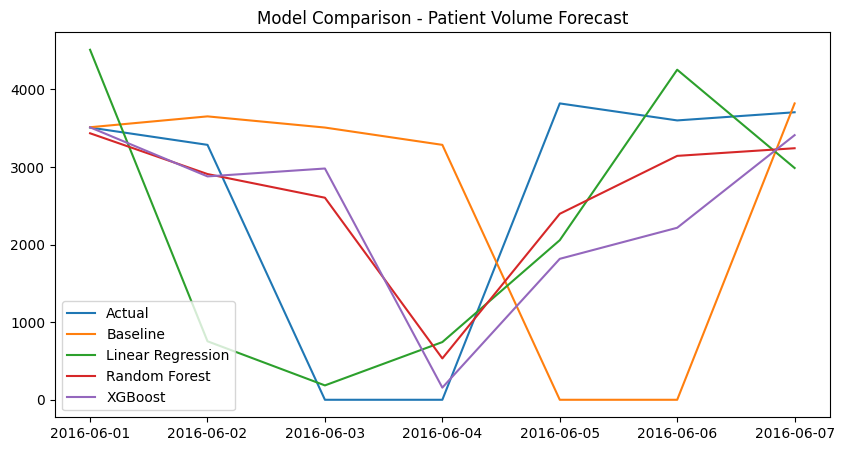

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_baseline, label="Baseline")
plt.plot(y_test.index, y_pred_lr, label="Linear Regression")
plt.plot(y_test.index, y_pred_rf, label="Random Forest")
plt.plot(y_test.index, y_pred_xgb, label="XGBoost")

plt.legend()
plt.title("Model Comparison - Patient Volume Forecast")
plt.show()

In [16]:
plt.savefig("../outputs/figures/model_comparison.png")

<Figure size 640x480 with 0 Axes>

## Feature Importance

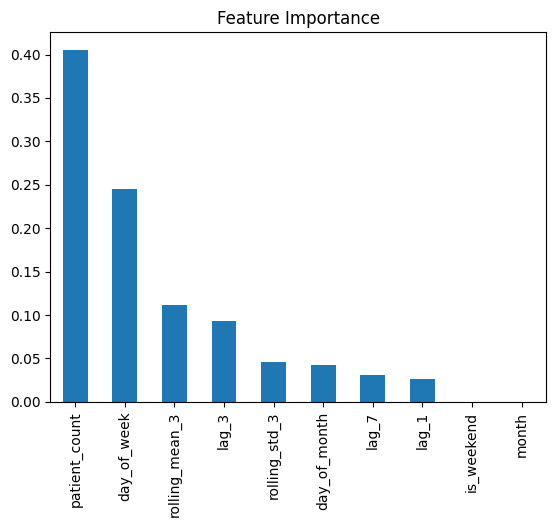

In [11]:
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

In [12]:
plt.savefig("../outputs/figures/feature_importance_ts.png")

<Figure size 640x480 with 0 Axes>

## Intepretation
**Key Findings**

- Lag features (especially lag_1) are the strongest predictors
- Short-term temporal patterns dominate forecasting performance
- Random forest is the best perfoming model

## Model Saving

In [17]:
import joblib

joblib.dump(rf_model, "../outputs/models/random_forest_model.pkl")

['../outputs/models/random_forest_model.pkl']